# Práctica 1: Perceptrón multicapa.

Tu jefe pidió a RH que recolectara datos de desempeño de tus compañeros, los resultados se almacenaron en un csv. El punto critico de estos datos es la satisfacción del empleado, entonces ¿Podremos estimar la satisfacción de los empleados con los datos recabados?.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models


df = pd.read_csv('Extended_Employee_Performance_and_Productivity_Data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

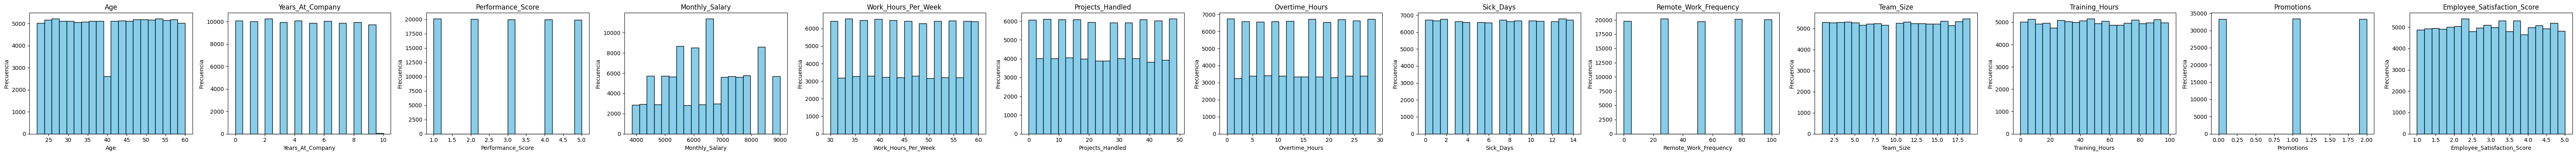

In [3]:
# Filtrar las columnas numéricas
numeric_columns = df.select_dtypes(include=['number']).drop('Employee_ID',axis=1)


# Si numeric_columns es un Index, conviértelo a lista
cols = list(numeric_columns)

fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 4))

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Problemas**, tenemos distribuciones con picos, esos nos indica categorías. Por otro lado, tenemos variables con "valles" en su distribución (distribuciones multimodales) por lo que resultaría óptimo aplicar técnicas de feature engeneering. Por último tenemos distribuciones uniformes, por lo que cada una requeriría un procesamiento indivudual, hagamos la vista gorda e intentemos ajustar un MLP con estos datos, solo estandaricemos nuestros datos.

---

## Implementación de Red:

To**memos los datos numéricos como nuestra variable X, y la variable objetivo como ***'Employee_Satisfaction_Score'***.
- **Actividad 1**: Para todos los strings ``'@modif@'`` que aparescan en el siguiente bloque de código cámbialos para que el código funcione.

In [4]:
X = numeric_columns.drop('Employee_Satisfaction_Score',axis = 1)
y = numeric_columns['Employee_Satisfaction_Score']
y = y.apply(lambda x: round(x)-1) #Cambiamos la variable objetivo a 5 categorías numéricas

scaler = StandardScaler()
X_standar = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_standar, y, test_size=0.33, random_state=42)

y_onehot_train = tf.keras.utils.to_categorical(y_train, 5)
y_onehot_test = tf.keras.utils.to_categorical(y_test,5)

- **Actividad 2:** Implementa 3 arquitecturas de MLP, cada una con su propio nombre, cambiando la estructura de dichas arquitecturas (capas, neuronas por capa, función de activación, etc). 

c:\Users\Lexingtonn\deep-learning-MLP\perceptr-n-multi-capa-Lexmago\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.2526 - loss: 1.5633 - val_accuracy: 0.2523 - val_loss: 1.5605
Epoch 2/50
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2607 - loss: 1.5554 - val_accuracy: 0.2525 - val_loss: 1.5612
Epoch 3/50
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2635 - loss: 1.5540 - val_accuracy: 0.2546 - val_loss: 1.5598
Epoch 4/50
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2660 - loss: 1.5532 - val_accuracy: 0.2539 - val_loss: 1.5601
Epoch 5/50
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2701 - loss: 1.5519 - val_accuracy: 0.2524 - val_loss: 1.5601
Epoch 6/50
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2703 - loss: 1.5512 - val_accuracy: 0.2518 - val_loss: 1.5602
Epoch 7/50
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.2734 - loss: 1.5501 - val_accuracy: 0.2544 - val_loss: 1.5606
Epoch 8/50
1675/1675 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2752 - loss: 1.548

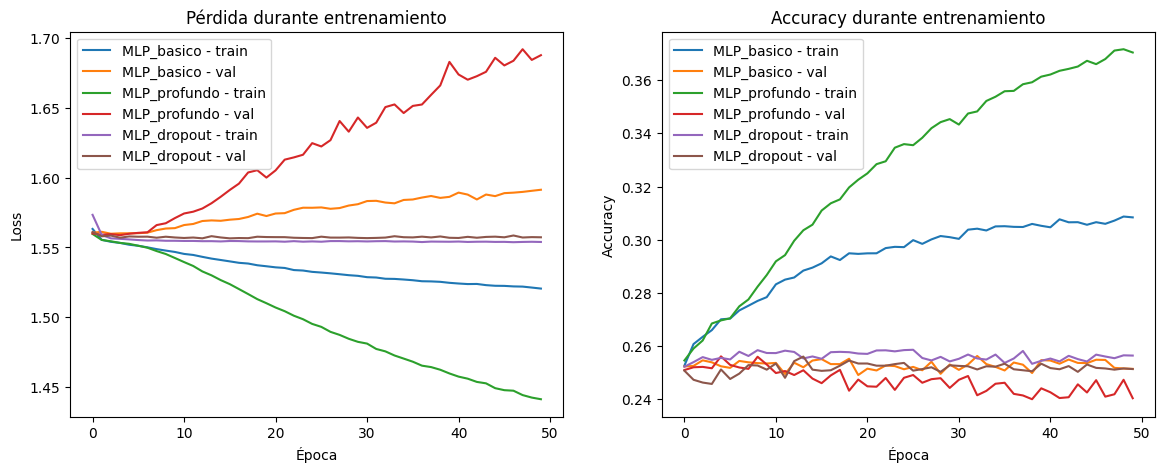

In [5]:
# ---------------------------
# IMPORTS
# ---------------------------
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


# ---------------------------
# DEFINICIÓN DE LAS 3 ARQUITECTURAS
# ---------------------------

# 1) MLP Básico
MLP_basico = Sequential(name='MLP_basico')
MLP_basico.add(Dense(64, input_shape=(X_train.shape[1],), activation='relu'))
MLP_basico.add(Dense(32, activation='relu'))
MLP_basico.add(Dense(5, activation='softmax'))

MLP_basico.compile(optimizer=Adam(0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])


# 2) MLP Profundo
MLP_profundo = Sequential(name='MLP_profundo')
MLP_profundo.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
MLP_profundo.add(Dense(64, activation='relu'))
MLP_profundo.add(Dense(32, activation='relu'))
MLP_profundo.add(Dense(5, activation='softmax'))

MLP_profundo.compile(optimizer=Adam(0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])


# 3) MLP con Dropout
MLP_dropout = Sequential(name='MLP_dropout')
MLP_dropout.add(Dense(128, input_shape=(X_train.shape[1],), activation='tanh'))
MLP_dropout.add(Dropout(0.3))
MLP_dropout.add(Dense(64, activation='relu'))
MLP_dropout.add(Dropout(0.2))
MLP_dropout.add(Dense(5, activation='softmax'))

MLP_dropout.compile(optimizer=Adam(0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])


# ---------------------------
# ENTRENAMIENTO
# ---------------------------
history_basico = MLP_basico.fit(X_train, y_onehot_train, validation_split=0.2,
                                epochs=50, batch_size=32, verbose=1)

history_profundo = MLP_profundo.fit(X_train, y_onehot_train, validation_split=0.2,
                                    epochs=50, batch_size=32, verbose=1)

history_dropout = MLP_dropout.fit(X_train, y_onehot_train, validation_split=0.2,
                                  epochs=50, batch_size=32, verbose=1)

# ---------------------------
# GRAFICAS DE LOSS Y ACCURACY
# ---------------------------
plt.figure(figsize=(14,5))

# Pérdida
plt.subplot(1,2,1)
plt.plot(history_basico.history['loss'], label='MLP_basico - train')
plt.plot(history_basico.history['val_loss'], label='MLP_basico - val')
plt.plot(history_profundo.history['loss'], label='MLP_profundo - train')
plt.plot(history_profundo.history['val_loss'], label='MLP_profundo - val')
plt.plot(history_dropout.history['loss'], label='MLP_dropout - train')
plt.plot(history_dropout.history['val_loss'], label='MLP_dropout - val')
plt.title('Pérdida durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_basico.history['accuracy'], label='MLP_basico - train')
plt.plot(history_basico.history['val_accuracy'], label='MLP_basico - val')
plt.plot(history_profundo.history['accuracy'], label='MLP_profundo - train')
plt.plot(history_profundo.history['val_accuracy'], label='MLP_profundo - val')
plt.plot(history_dropout.history['accuracy'], label='MLP_dropout - train')
plt.plot(history_dropout.history['val_accuracy'], label='MLP_dropout - val')
plt.title('Accuracy durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


- **Actividad 3:** Compila y ajusta tus tres modelos con sus respectivos hiperparámetros.

Epoch 1/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2479 - loss: 1.6331 - val_accuracy: 0.2566 - val_loss: 1.6054
Epoch 2/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2576 - loss: 1.5968 - val_accuracy: 0.2560 - val_loss: 1.5902
Epoch 3/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2602 - loss: 1.5828 - val_accuracy: 0.2529 - val_loss: 1.5798
Epoch 4/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2616 - loss: 1.5731 - val_accuracy: 0.2567 - val_loss: 1.5725
Epoch 5/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2595 - loss: 1.5669 - val_accuracy: 0.2504 - val_loss: 1.5671
Epoch 6/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2558 - loss: 1.5627 - val_accuracy: 0.2540 - val_loss: 1.5635
Epoch 7/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.2624 - loss: 1.5596 - val_accuracy: 0.2520 - val_loss: 1.5611
Epoch 8/100
838/838 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2603 - loss: 1.5577 - val_accu

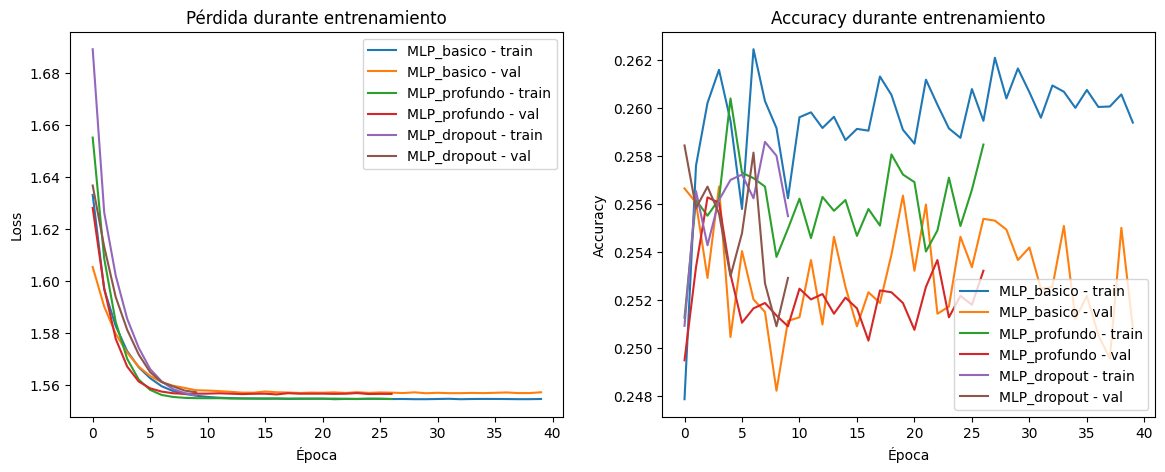

In [6]:
# ---------------------------
# IMPORTS
# ---------------------------
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


# ---------------------------
# CALLBACKS
# ---------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


# ---------------------------
# DEFINICIÓN DE LAS 3 ARQUITECTURAS
# ---------------------------

# 1) MLP Básico (con regularización)
MLP_basico = Sequential(name='MLP_basico')
MLP_basico.add(Dense(64, input_shape=(X_train.shape[1],), activation='relu', kernel_regularizer=l2(0.001)))
MLP_basico.add(Dropout(0.3))
MLP_basico.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
MLP_basico.add(Dense(5, activation='softmax'))

MLP_basico.compile(optimizer=Adam(learning_rate=0.0005),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])


# 2) MLP Profundo (más capas + dropout)
MLP_profundo = Sequential(name='MLP_profundo')
MLP_profundo.add(Dense(128, input_shape=(X_train.shape[1],), activation='relu', kernel_regularizer=l2(0.001)))
MLP_profundo.add(Dropout(0.4))
MLP_profundo.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
MLP_profundo.add(Dropout(0.3))
MLP_profundo.add(Dense(32, activation='relu'))
MLP_profundo.add(Dense(5, activation='softmax'))

MLP_profundo.compile(optimizer=Adam(learning_rate=0.0005),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])


# 3) MLP con Dropout (ya lo tenías, mejorado con regularización)
MLP_dropout = Sequential(name='MLP_dropout')
MLP_dropout.add(Dense(128, input_shape=(X_train.shape[1],), activation='tanh', kernel_regularizer=l2(0.001)))
MLP_dropout.add(Dropout(0.5))
MLP_dropout.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
MLP_dropout.add(Dropout(0.3))
MLP_dropout.add(Dense(5, activation='softmax'))

MLP_dropout.compile(optimizer=Adam(learning_rate=0.0005),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])


# ---------------------------
# ENTRENAMIENTO
# ---------------------------
history_basico = MLP_basico.fit(X_train, y_onehot_train, validation_split=0.2,
                                epochs=100, batch_size=64, verbose=1, callbacks=[early_stop])

history_profundo = MLP_profundo.fit(X_train, y_onehot_train, validation_split=0.2,
                                    epochs=100, batch_size=64, verbose=1, callbacks=[early_stop])

history_dropout = MLP_dropout.fit(X_train, y_onehot_train, validation_split=0.2,
                                  epochs=100, batch_size=64, verbose=1, callbacks=[early_stop])


# ---------------------------
# GRAFICAS DE LOSS Y ACCURACY
# ---------------------------
plt.figure(figsize=(14,5))

# Pérdida
plt.subplot(1,2,1)
plt.plot(history_basico.history['loss'], label='MLP_basico - train')
plt.plot(history_basico.history['val_loss'], label='MLP_basico - val')
plt.plot(history_profundo.history['loss'], label='MLP_profundo - train')
plt.plot(history_profundo.history['val_loss'], label='MLP_profundo - val')
plt.plot(history_dropout.history['loss'], label='MLP_dropout - train')
plt.plot(history_dropout.history['val_loss'], label='MLP_dropout - val')
plt.title('Pérdida durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history_basico.history['accuracy'], label='MLP_basico - train')
plt.plot(history_basico.history['val_accuracy'], label='MLP_basico - val')
plt.plot(history_profundo.history['accuracy'], label='MLP_profundo - train')
plt.plot(history_profundo.history['val_accuracy'], label='MLP_profundo - val')
plt.plot(history_dropout.history['accuracy'], label='MLP_dropout - train')
plt.plot(history_dropout.history['val_accuracy'], label='MLP_dropout - val')
plt.title('Accuracy durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# Conclusiones
Se hizo un reajuste de hiperparametros para mejorar el aprendizaje del modelo. Se logró reducir la función de perdida para los 3 modelos, sin embargo la accuracy aun tiene algo de ruido estadistico. El MLP_basico es el mejor modelo hasta ahorita en cuanto a precisión, es por el que me iría yo para este data set. Ahora tocaría enfocarse en mejorar la presición.

- **Actividad 4:** Sube tus cambios al repositorio, envía el link de tu repositorio a la actividad 2 de tu checkpoint 2 y contesta las preguntas de dicha actividad.